Name    : Bhima Fairul Rifqi

NIM     : 25/579939/PPA/07301

In [ ]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr

# 1. Image Sharpening

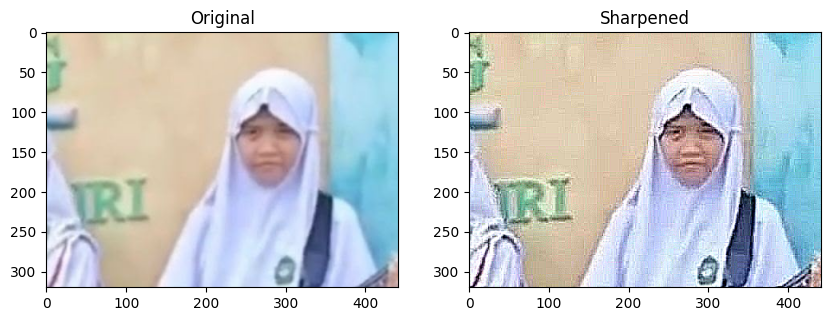

True

In [ ]:
# Read the image from the specified file path
img_1 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/panya.jpeg')

# Convert the image from BGR (OpenCV default) to RGB format
image_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)

# Define a sharpening kernel to enhance the edges and details of the image
kernel_1 = np.array([[-2, -2, -2],
                     [-2, 17, -2],
                     [-2, -2, -2]])

# Apply the sharpening kernel to the image using a 2D convolution filter
sharpened = cv2.filter2D(image_1, -1, kernel_1)

# Plot the original and sharpened images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image_1)
ax[0].set_title('Original')

# Display the sharpened image
ax[1].imshow(sharpened)
ax[1].set_title('Sharpened')

# Show the plotted images
plt.show()

# Save the result
cv2.imwrite('sharpened.jpg', sharpened)

In [ ]:
# Evaluation using PSNR

psnr_score = psnr(image_1, sharpened)
print(f"PSNR Score of the result: {psnr_score:.2f} dB")

PSNR Score of the result: 22.45 dB


As we can see from the output, the resulting image is more sharpened than the original one.

A PSNR score of 22.45 dB represents a moderate-to-high level of pixel-wise difference between the original and processed images. In the context of image sharpening, a lower or moderate PSNR is expected and typical: sharpening intentionally boosts edge contrast and high-frequency details, which causes significant mathematical deviation from the original pixel values despite improving visual crispness.

# 2. Blurring Image / Over Sharpened

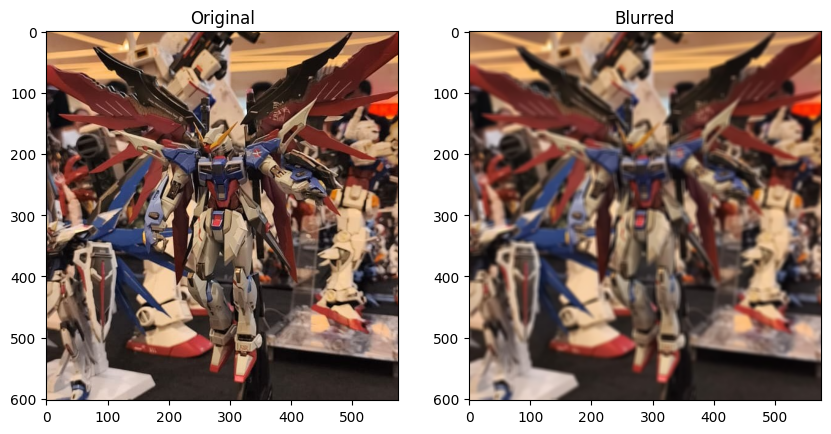

True

In [ ]:
# Read the image from the specified file path
img_2 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/gundam.jpeg')

# Convert the image from BGR (OpenCV default) to RGB format
image_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)

# Define a box blur kernel matrix to smooth the image
kernel_2 = np.array([[1, 1, 1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1, 1, 1]])

# Normalize the kernel by dividing by the total number of elements
kernel_2 = (1/49) * kernel_2

# Apply the blurring kernel to the image using a 2D convolution filter
blurred = cv2.filter2D(image_2, -1, kernel_2)

# Plot the original and blurred images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image_2)
ax[0].set_title('Original')

# Display the blurred image
ax[1].imshow(blurred)
ax[1].set_title('Blurred')

# Show the plotted images
plt.show()

# Save the result
cv2.imwrite('blurred.jpg', blurred)

In [ ]:
# Evaluation using PSNR

psnr_score = psnr(image_2, blurred)
print(f"PSNR Score of the result: {psnr_score:.2f} dB")

PSNR Score of the result: 23.13 dB


As we can see from the output, the resulting image is more blurry than the original one.

A PSNR score of 23.13 dB indicates a moderate level of structural deviation from the original image. For blurring, a lower to moderate score is expected because smoothing filters strip away fine high-frequency details and soften sharp contrast boundaries, intentionally shifting the pixel values away from the original raw data.

# 3. Too Bright

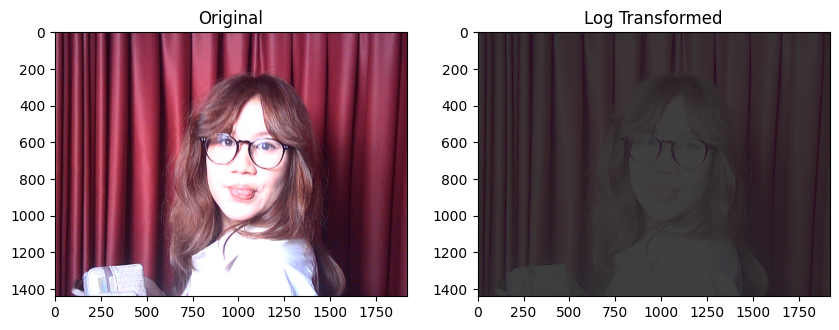

True

In [ ]:
# Read the image from the specified file path
img_3 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/too_bright.jpg')

# Convert the image from BGR (OpenCV default) to RGB format
image_3 = cv2.cvtColor(img_3, cv2.COLOR_BGR2RGB)

# Convert the image data type to float to prevent calculation overflow
image_float = np.float32(image_3)

# Calculate the scaling constant c for the log transform
c = 90 / np.log(1 + np.max(image_float))

# Apply the logarithmic transformation to adjust image brightness
log_transformed = (c * 0.7) * np.log(1 + image_float)

# Convert the image back to 8-bit unsigned integer format
log_transformed = np.uint8(log_transformed)

# Plot the original and log-transformed images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image_3)
ax[0].set_title('Original')

# Display the log-transformed image
ax[1].imshow(log_transformed)
ax[1].set_title('Log Transformed')

# Show the plotted images
plt.show()

# Save the result
cv2.imwrite('log_transformed_darker.jpg', log_transformed)

In [ ]:
# Evaluation using PSNR

psnr_score = psnr(image_3, log_transformed)
print(f"PSNR Score of the result: {psnr_score:.2f} dB")

PSNR Score of the result: 9.45 dB


As we can see from the output, the resulting image is darker than the original one.

A PSNR score of 9.45 dB is very low, indicating a massive pixel-level deviation from the original image. Because darkening significantly shifts intensity values across almost every pixel, the overall mathematical difference from the source image is severe, resulting in a low signal-to-noise ratio even if the visual structures remain recognizable.

# 4. Too Dark

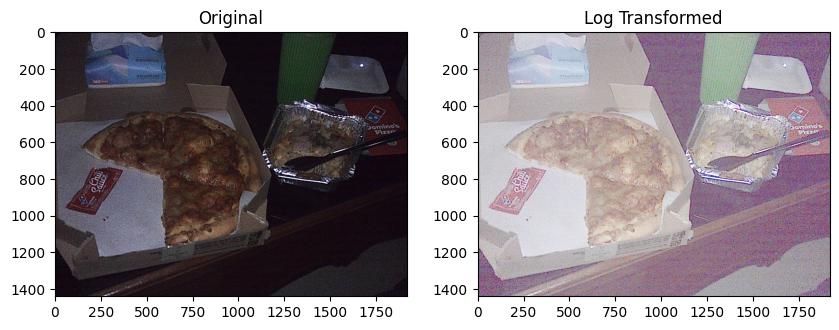

True

In [ ]:
# Read the image from the specified file path
img_4 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/too_dark.jpg')

# Convert the image from BGR (OpenCV default) to RGB format
image_4 = cv2.cvtColor(img_4, cv2.COLOR_BGR2RGB)

# Convert the image data type to float to prevent calculation overflow
image_float = np.float32(image_4)

# Calculate the scaling constant c for the log transform
c = 255 / np.log(1 + np.max(image_float))

# Apply the logarithmic transformation to adjust image brightness
log_transformed = (c) * np.log(1 + image_float)

# Convert the image back to 8-bit unsigned integer format
log_transformed = np.uint8(log_transformed)

# Plot the original and log-transformed images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image_4)
ax[0].set_title('Original')

# Display the log-transformed image
ax[1].imshow(log_transformed)
ax[1].set_title('Log Transformed')

# Show the plotted images
plt.show()

# Save the result
cv2.imwrite('log_transformed_brighter.jpg', log_transformed)

In [ ]:
# Evaluation using PSNR

psnr_score = psnr(image_4, log_transformed)
print(f"PSNR Score of the result: {psnr_score:.2f} dB")

PSNR Score of the result: 6.61 dB


As we can see from the output, the resulting image is brighter than the original one.

A PSNR score of 6.61 dB is exceptionally low, representing a severe mathematical divergence from the original pixel values. Brightening an image causes a massive global increase in luminance across most pixels, which generates a very high Mean Squared Error (MSE) and results in a low fidelity score relative to the source image.

# 5. Noise

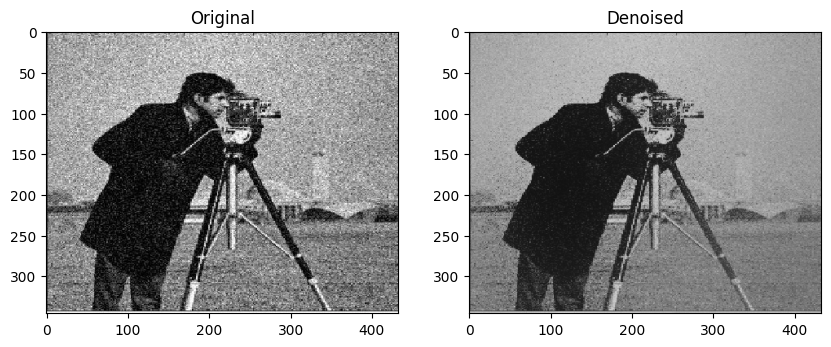

True

In [ ]:
# Read the image from the specified file path
image_5 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/noise.jpg')

# Apply a bilateral filter to reduce noise while preserving edges
denoised = cv2.bilateralFilter(image_5, d=150, sigmaColor=150, sigmaSpace=150)

# Plot the original and denoised images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image_5)
ax[0].set_title('Original')

# Display the denoised image
ax[1].imshow(denoised)
ax[1].set_title('Denoised')

# Show the plotted images
plt.show()

# Save the result
cv2.imwrite('denoised_median.jpg', denoised)

In [ ]:
# Evaluation using PSNR

psnr_score = psnr(image_5, denoised)
print(f"PSNR Score of the result: {psnr_score:.2f} dB")

PSNR Score of the result: 21.74 dB


As we can see from the output, the resulting image is less noisy (denoised) than the original one.

A PSNR score of 21.74 dB indicates a moderate level of structural difference from the original input. During denoising, smoothing or filtering algorithms actively alter individual pixel values to smooth out unwanted noise, which mathematically shifts the processed image away from the raw noisy input and produces a moderate fidelity score.

# 6. Low Contrast

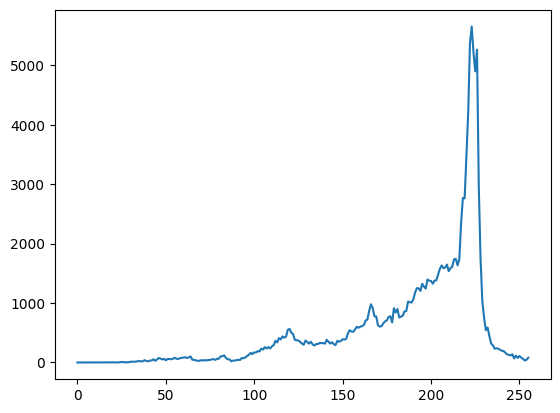

In [ ]:
# Read the image from the specified file path
img_6 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/panya.jpeg')

# Convert the image from BGR (OpenCV default) to RGB format
image_6 = cv2.cvtColor(img_6, cv2.COLOR_BGR2RGB)

# Calculate the pixel intensity histogram for the original image
hist = cv2.calcHist([image_6], [0], None, [256], [0, 256])

# Plot the histogram values
plt.plot(hist)

# Show the plot
plt.show()

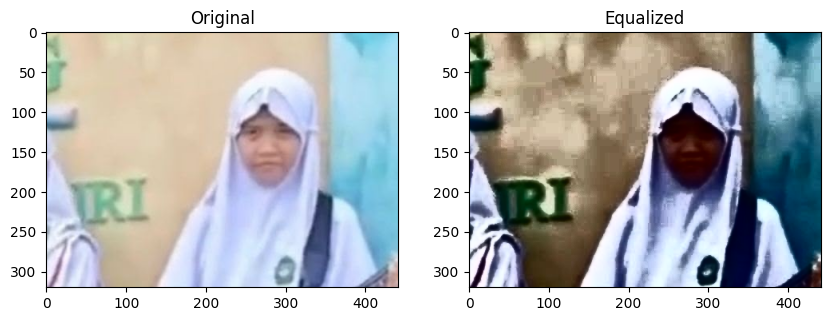

True

In [ ]:
# Convert the image from BGR to YCrCb color space
img_ycrcb = cv2.cvtColor(img_6, cv2.COLOR_BGR2YCrCb)

# Equalize the histogram of the luminance (Y) channel
img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])

# Convert the image back to BGR and then to RGB format
equalized_bgr = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2BGR)
equalized_rgb = cv2.cvtColor(equalized_bgr, cv2.COLOR_BGR2RGB)

# Plot the original and equalized images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display the original image
ax[0].imshow(image_6)
ax[0].set_title('Original')

# Display the equalized image
ax[1].imshow(equalized_rgb)
ax[1].set_title('Equalized')

# Show the plotted images
plt.show()

# Save the result
cv2.imwrite('equalized.jpg', equalized_rgb)

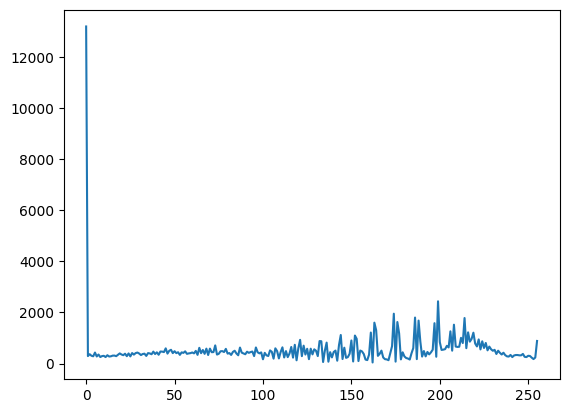

In [ ]:
# Calculate the pixel intensity histogram for the equalized image
hist = cv2.calcHist([equalized_rgb], [0], None, [256], [0, 256])

# Plot the histogram values
plt.plot(hist)

# Show the plot
plt.show()

In [ ]:
# Evaluation using PSNR

psnr_score = psnr(image_6, equalized_rgb)
print(f"PSNR Score of the result: {psnr_score:.2f} dB")

PSNR Score of the result: 9.71 dB


As we can see from the output, the resulting image has lower contrast than the original one.

A PSNR score of 9.71 dB is very low, indicating a significant pixel-level deviation from the original image. Reducing contrast compresses the overall dynamic range and systematically shifts pixel intensities across the entire image toward mid-gray tones, generating a high Mean Squared Error (MSE) and yielding a low fidelity score relative to the source.

# 7. Low Resolution

In [ ]:
from PIL import Image

# Read the image from the specified file path
img_7 = Image.open("/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/panya.jpeg")

# Calculate the new dimensions to double the original image size
new_size = (img_7.width * 2, img_7.height * 2)

# Resize the image using Lanczos resampling
upscaled = img_7.resize(new_size, Image.Resampling.LANCZOS)

# Save the result
upscaled.save("upscaled.jpg", quality=95)

In [ ]:
# Read the image from the specified file path
img_7 = cv2.imread('/content/drive/MyDrive/Kuliah/Semester 1/CVL/Dataset/panya.jpeg')

# Convert the image from BGR (OpenCV default) to RGB format
image_7 = cv2.cvtColor(img_7, cv2.COLOR_BGR2RGB)

# Print the original image dimensions and channel information
print("Shape of original image:", image_7.shape)

Shape of original image: (320, 442, 3)


array([[[217, 213, 175],
        [216, 212, 174],
        [216, 211, 173],
        ...,
        [155, 220, 242],
        [159, 219, 243],
        [159, 219, 243]],

       [[217, 213, 175],
        [217, 213, 175],
        [216, 212, 174],
        ...,
        [155, 220, 242],
        [158, 220, 243],
        [159, 219, 243]],

       [[217, 215, 176],
        [217, 215, 176],
        [216, 214, 175],
        ...,
        [156, 221, 243],
        [158, 220, 243],
        [158, 220, 243]],

       ...,

       [[235, 221, 244],
        [223, 209, 232],
        [211, 195, 221],
        ...,
        [199, 171, 170],
        [198, 169, 171],
        [195, 166, 168]],

       [[231, 217, 242],
        [213, 199, 224],
        [194, 178, 205],
        ...,
        [200, 171, 173],
        [190, 161, 165],
        [185, 159, 162]],

       [[223, 209, 234],
        [202, 188, 213],
        [179, 163, 190],
        ...,
        [201, 172, 174],
        [184, 158, 161],
        [181, 155, 158]]], dtype=uint8)
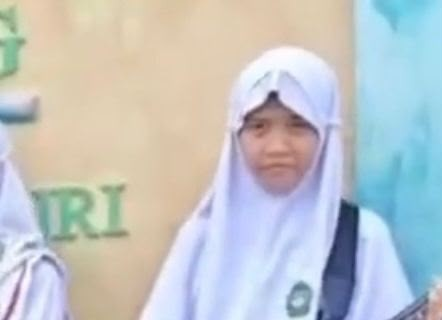

In [ ]:
image_7

In [ ]:
# Read the image from the specified file path
img = cv2.imread('upscaled.jpg')

# Print the original image dimensions and channel information
print("Shape of upscaled image:", img.shape)

Shape of upscaled image: (640, 884, 3)


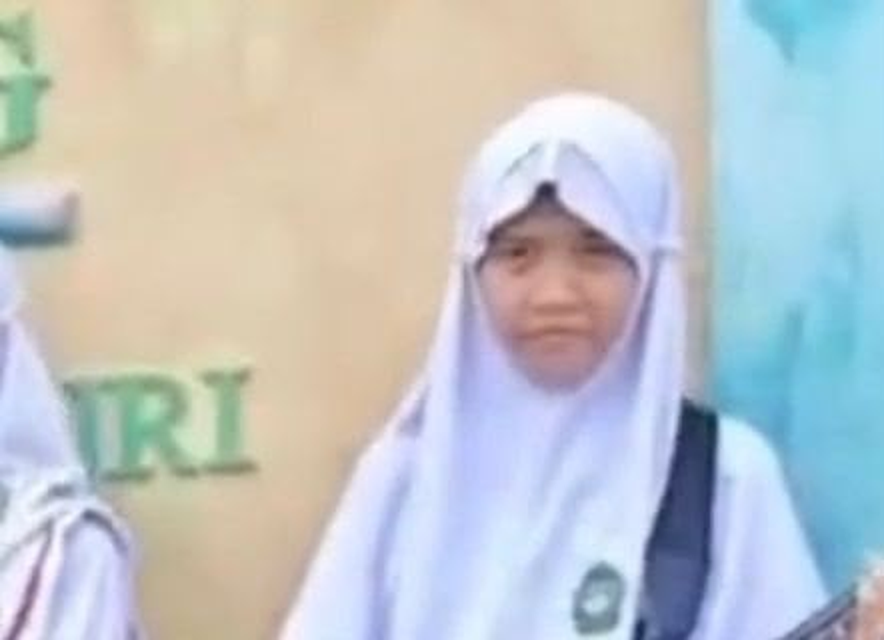

In [ ]:
upscaled

As we can see from the output, the original image shape is (320, 442, 3), whereas the upscaled image shape is (640, 884, 3).


The output shows a exact 2x spatial resolution increase along both dimensions, with the height increasing from 320 to 640 pixels and the width from 442 to 884 pixels. Because both dimensions have doubled, the total pixel count increases by a factor of 4 (from 141,440 pixels to 565,760 pixels), providing higher spatial density while maintaining the original 3 color channels (RGB).